In [79]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

import numpy as np
from matplotlib.gridspec import GridSpec
from qubo_solvers.plotting_helpers import radar_factory, get_compare_solver_data, get_compare_annotator_data, get_violin_plot_data

In [80]:
solver_names = {
    "dwave": "DWave",
    "mqlib": "MQLib",
    "gurobi": "Gurobi",
    "pathfinder": "Pathfinder"
}
annotator_names = {
    "mg": "Minigraph",
    "km": "Kmer2node",
    "ga": "GraphAligner"
}
solver_colours = {
     "gurobi": '#5366E0',
    "mqlib": '#13553A',
    "pathfinder": '#911449',
    "dwave": "#FD8153"
}

dtype="cons"


# data_folder = '/nfs/users/nfs_j/jc59/quantumwork/pangenome/out/pathfinder_copy_numbers_harder_cons_20_5.60.120.300_3_5'
# solvers = ["gurobi", "mqlib", "pathfinder"]
data_folder = '/nfs/users/nfs_j/jc59/quantumwork/pangenome/out/remake_dwave'
solvers = ["dwave", "pathfinder"]

TEXTWIDTH_IN = 6.27   # journal text width in inches (8.27 - 1in margin each side)
DPI = 300

3 7 2
0.6759999999999999


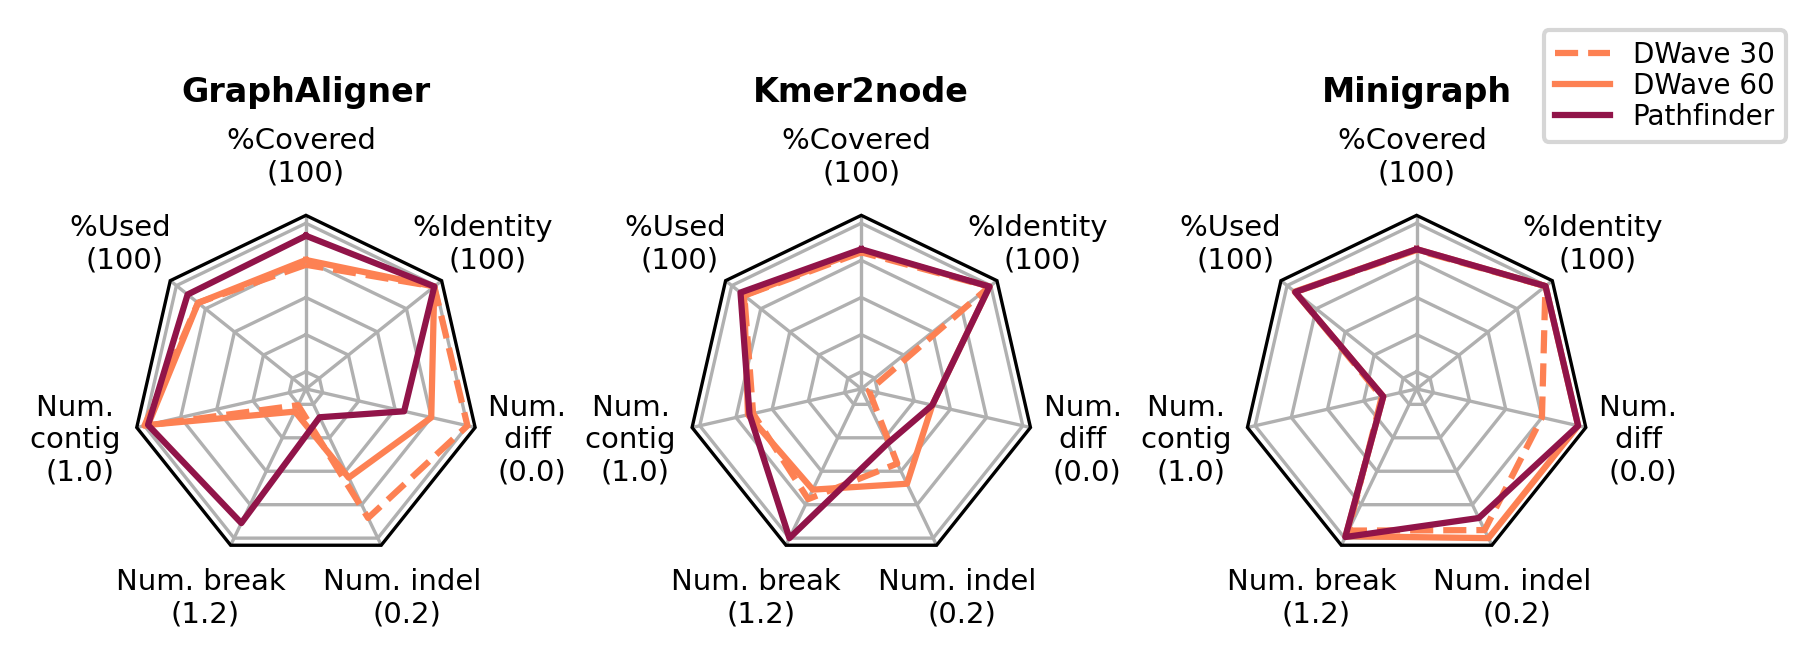

In [81]:
data, spoke_labels, labels = get_compare_annotator_data(data_folder, dtype, solvers)
ncols = len(data) 
N = data[0][1].shape[1] 
num_time_limits = int((data[0][1].shape[0] - 1)/(len(solvers) - 1))
theta = radar_factory(N, frame='polygon')
print(ncols, N, num_time_limits)
    
FIG_HEIGHT_IN = 4.0   
min_panel_in = 2.5
inch_per_spoke = 0.25   

req_widths_in = [max(min_panel_in, N * inch_per_spoke) for _ in range(ncols)]
gap_in = 0.60   
total_req_in = sum(req_widths_in) + gap_in*(ncols-1)
if total_req_in <= TEXTWIDTH_IN:
    panel_widths_in = req_widths_in
else:
    scale = (TEXTWIDTH_IN - gap_in*(ncols-1)) / sum(req_widths_in)
    print(scale)
    panel_widths_in = [w*scale for w in req_widths_in]

width_ratios = panel_widths_in

plt.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.size": 8,            
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig = plt.figure(figsize=(TEXTWIDTH_IN, FIG_HEIGHT_IN), dpi=DPI)
gs = GridSpec(1, ncols, figure=fig, width_ratios=width_ratios, wspace=gap_in)

axs = []
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection='radar', sharey=axs[0] if len(axs) else None)
    axs.append(ax)
axs = np.array(axs)
    
colors = [solver_colours[solver] for solver in solvers]
styles = [':', '-.', '--', '-']

colors_for_lines = list(
    np.array(
        [[colors[i]] * num_time_limits for i in range(len(solvers))]
    ).reshape((num_time_limits * len(solvers),))
) + [colors[-1]]
styles_for_lines = styles[-num_time_limits:] * (len(solvers)-1) + [styles[-1]]

for ax, (title, case_data) in zip(axs.flat, data):
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8,1])
    ax.set_title(annotator_names[title], weight='bold', size='medium', position=(0.5, 1.5),
                    horizontalalignment='center')
    for i in range(case_data.shape[0]):
        ax.plot(theta, case_data[i,:], color=colors_for_lines[i], linestyle=styles_for_lines[i])  
    ax.set_varlabels(spoke_labels)
    ax.set_yticklabels([])

legend = axs[-1].legend(labels, loc='upper left', bbox_to_anchor=(0.85, 1.55),
                       borderaxespad=0.2, labelspacing=0.1, fontsize='small')

plt.show()
figname = f'{data_folder}/compare_annotator.{".".join(solvers)}.png'
fig.savefig(figname, dpi=DPI, bbox_inches='tight')


2 7 2
0.7277039999999999


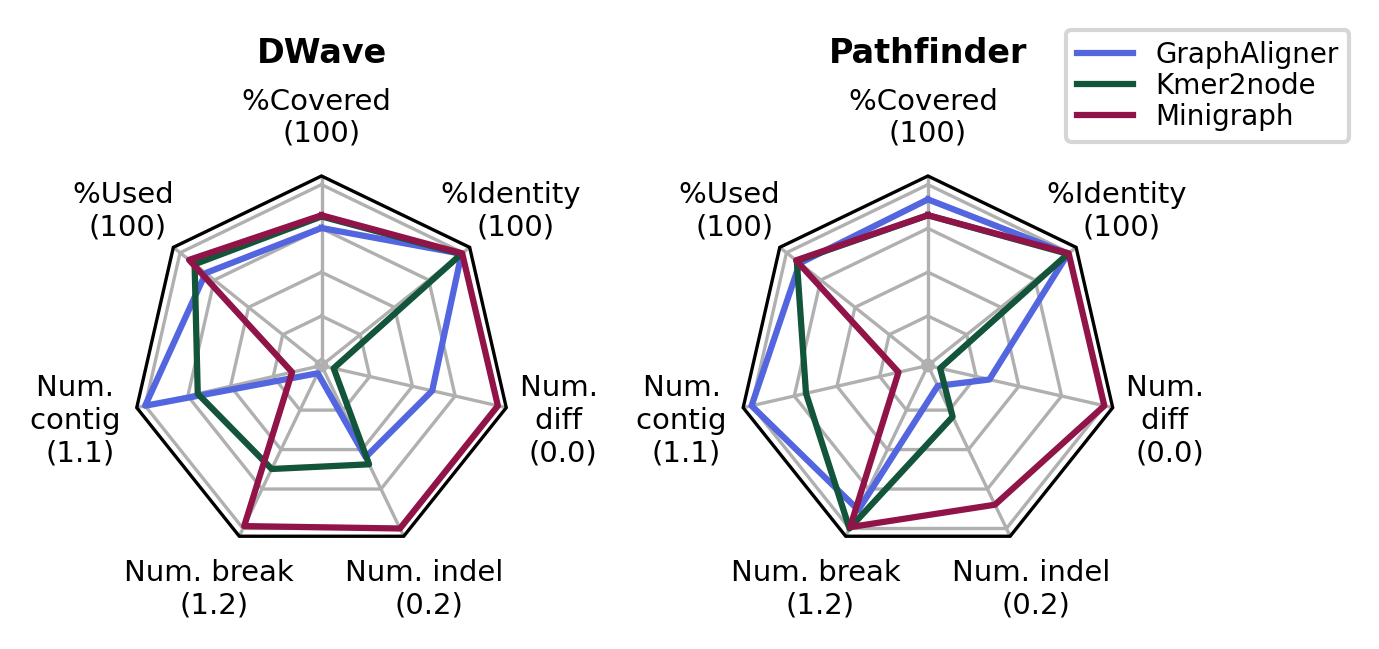

In [82]:
data, spoke_labels, labels = get_compare_solver_data(data_folder, dtype, solvers)
ncols = len(solvers) 
N = data[0][1].shape[1] 
num_time_limits = int((data[0][1].shape[0] - 1)/(len(solvers) - 1))
theta = radar_factory(N, frame='polygon')
num_annotators = 3
print(ncols, N, num_time_limits)

if len(solvers) == 2:
    scale_factor = 0.6759999999999999
else:
    scale_factor = 1


FIG_HEIGHT_IN = 4.0   
min_panel_in = 2.5
inch_per_spoke = 0.25   

req_widths_in = [max(min_panel_in, N * inch_per_spoke) for _ in range(ncols)]
gap_in = 0.60   


total_req_in = sum(req_widths_in) + gap_in*(ncols-1)
if total_req_in <= TEXTWIDTH_IN * scale_factor:
    panel_widths_in = req_widths_in
else:
    scale = (TEXTWIDTH_IN * scale_factor - gap_in*(ncols-1)) / sum(req_widths_in)
    print(scale)
    panel_widths_in = [w*scale for w in req_widths_in]

width_ratios = panel_widths_in

plt.rcParams.update({
    "figure.dpi": DPI,
    "savefig.dpi": DPI,
    "font.size": 8,            
    "axes.titlesize": 10,
    "axes.labelsize": 8,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "legend.fontsize": 7,
})

fig = plt.figure(figsize=(TEXTWIDTH_IN* scale_factor, FIG_HEIGHT_IN), dpi=DPI)
gs = GridSpec(1, ncols, figure=fig, width_ratios=width_ratios, wspace=gap_in)

axs = []
for i in range(ncols):
    ax = fig.add_subplot(gs[0, i], projection='radar', sharey=axs[0] if len(axs) else None)
    axs.append(ax)
axs = np.array(axs)
    
colors = [solver_colours[solver] for solver in solvers]
styles = [':', '-.', '--', '-']

colors_for_lines = list(solver_colours.values())[:num_annotators]
styles_for_lines = ['-'] * num_annotators

for ax, (title, case_data) in zip(axs.flat, data):
    ax.set_rgrids([0.2, 0.4, 0.6, 0.8,1])
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.5),
                    horizontalalignment='center')
    for i in range(case_data.shape[0]):
        ax.plot(theta, case_data[i,:], color=colors_for_lines[i], linestyle=styles_for_lines[i])  
    ax.set_varlabels(spoke_labels)
    ax.set_yticklabels([])


legend = axs[-1].legend(labels, loc='upper left', bbox_to_anchor=(0.85, 1.40 if len(solvers) == 2 else 1.45), # (0.85, 1.55)
                       borderaxespad=0.2, labelspacing=0.1, fontsize='small')

plt.show()
figname = f'{data_folder}/compare_solver.{".".join(solvers)}.png'
fig.savefig(figname, dpi=DPI, bbox_inches='tight')


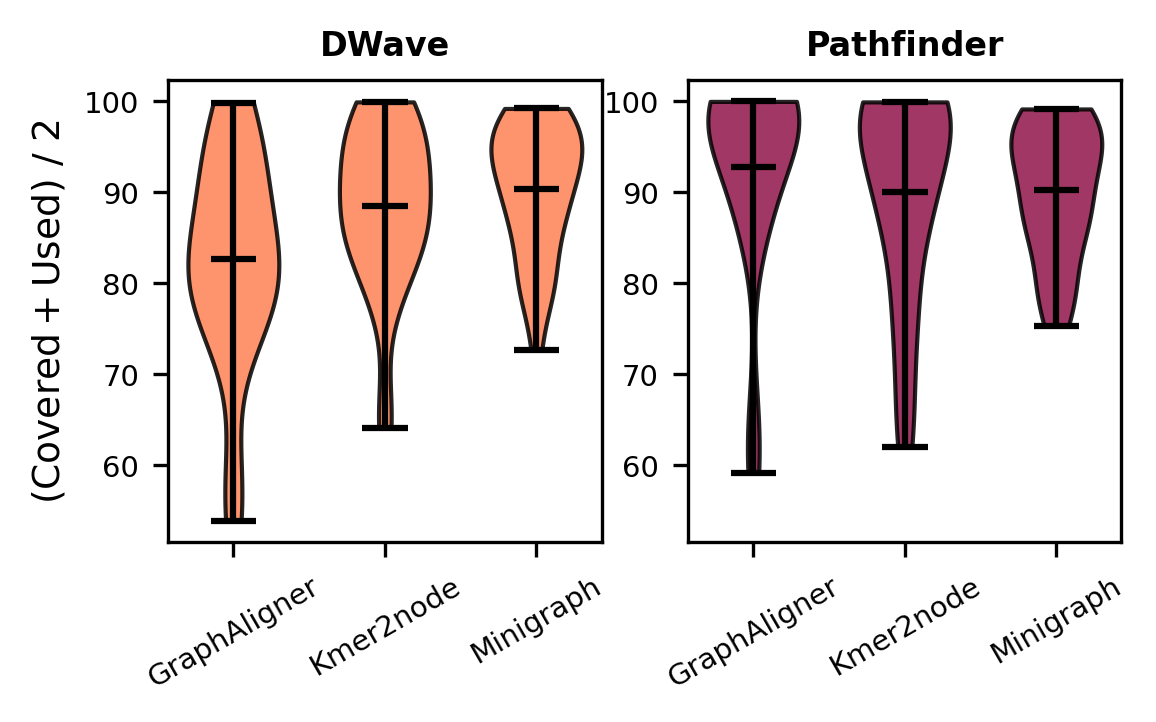

In [83]:
data, line_labels = get_violin_plot_data(data_folder, dtype, solvers)

textwidth_in = 6.27
dpi = 300              
height_in = 2.0

ncols = len(solvers)    
num_annotators = 3


gap_in = 0.2
min_subplot_in = 1.8
inch_per_xtick = 0.35

fig_w_in = (min_subplot_in * ncols) + (gap_in * (ncols-1)) + 0.3
fig_h_in = height_in


xt_counts = [num_annotators] * len(solvers) 
req_widths = [max(min_subplot_in, c * inch_per_xtick) for c in xt_counts]
total_req = sum(req_widths) + gap_in*(ncols-1)

if total_req <= fig_w_in:
    subplot_widths = req_widths
else:
    scale = (fig_w_in - gap_in*(ncols-1)) / sum(req_widths)
    subplot_widths = [w*scale for w in req_widths]


plt.rcParams.update({
    "figure.figsize": (fig_w_in, fig_h_in),
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": 8,            
    "axes.titlesize": 10,
    "axes.labelsize": 9,       
    "xtick.labelsize": 7,      
    "ytick.labelsize": 7,
    "legend.fontsize": 8,
    "axes.titlepad": 6,
})

fig = plt.figure(figsize=(fig_w_in, fig_h_in), dpi=dpi)
gs = GridSpec(1, ncols, figure=fig, wspace=gap_in,
              width_ratios=subplot_widths)

axs = [fig.add_subplot(gs[0, 0])]
axs.extend([fig.add_subplot(gs[0, i], sharey=axs[0]) for i in range(1, ncols)])

violin_width = 0.6
for ax_idx, ax in enumerate(axs):
    col = solver_colours[solvers[ax_idx]]
    slice_data = data[(ax_idx)*num_annotators:(ax_idx+1)*num_annotators]
    xticks = line_labels[(ax_idx)*num_annotators:(ax_idx+1)*num_annotators]
    title = solver_names[solvers[ax_idx]]

    parts = ax.violinplot(slice_data, showmeans=True, widths=violin_width, points=100)
    for pc in parts['bodies']:
        pc.set_facecolor(col); pc.set_edgecolor('black'); pc.set_alpha(0.85)
    for name in ('cmeans', 'cbars', 'cmins', 'cmaxes'):
        if name in parts:
            parts[name].set_color('black')

    ax.set_xticks(np.arange(1, len(xticks)+1))
    ax.set_xticklabels(xticks, rotation=30, ha='center')  
    ax.set_title(title, weight='bold', size='medium', position=(0.5, 1.5),
                horizontalalignment='center')

axs[0].set_ylabel(r'$(\text{Covered} + \text{Used})\ / \ 2$')

figname = f'{data_folder}/violin.{".".join(solvers)}.png'
fig.savefig(figname, dpi=dpi, bbox_inches='tight')   
plt.show()


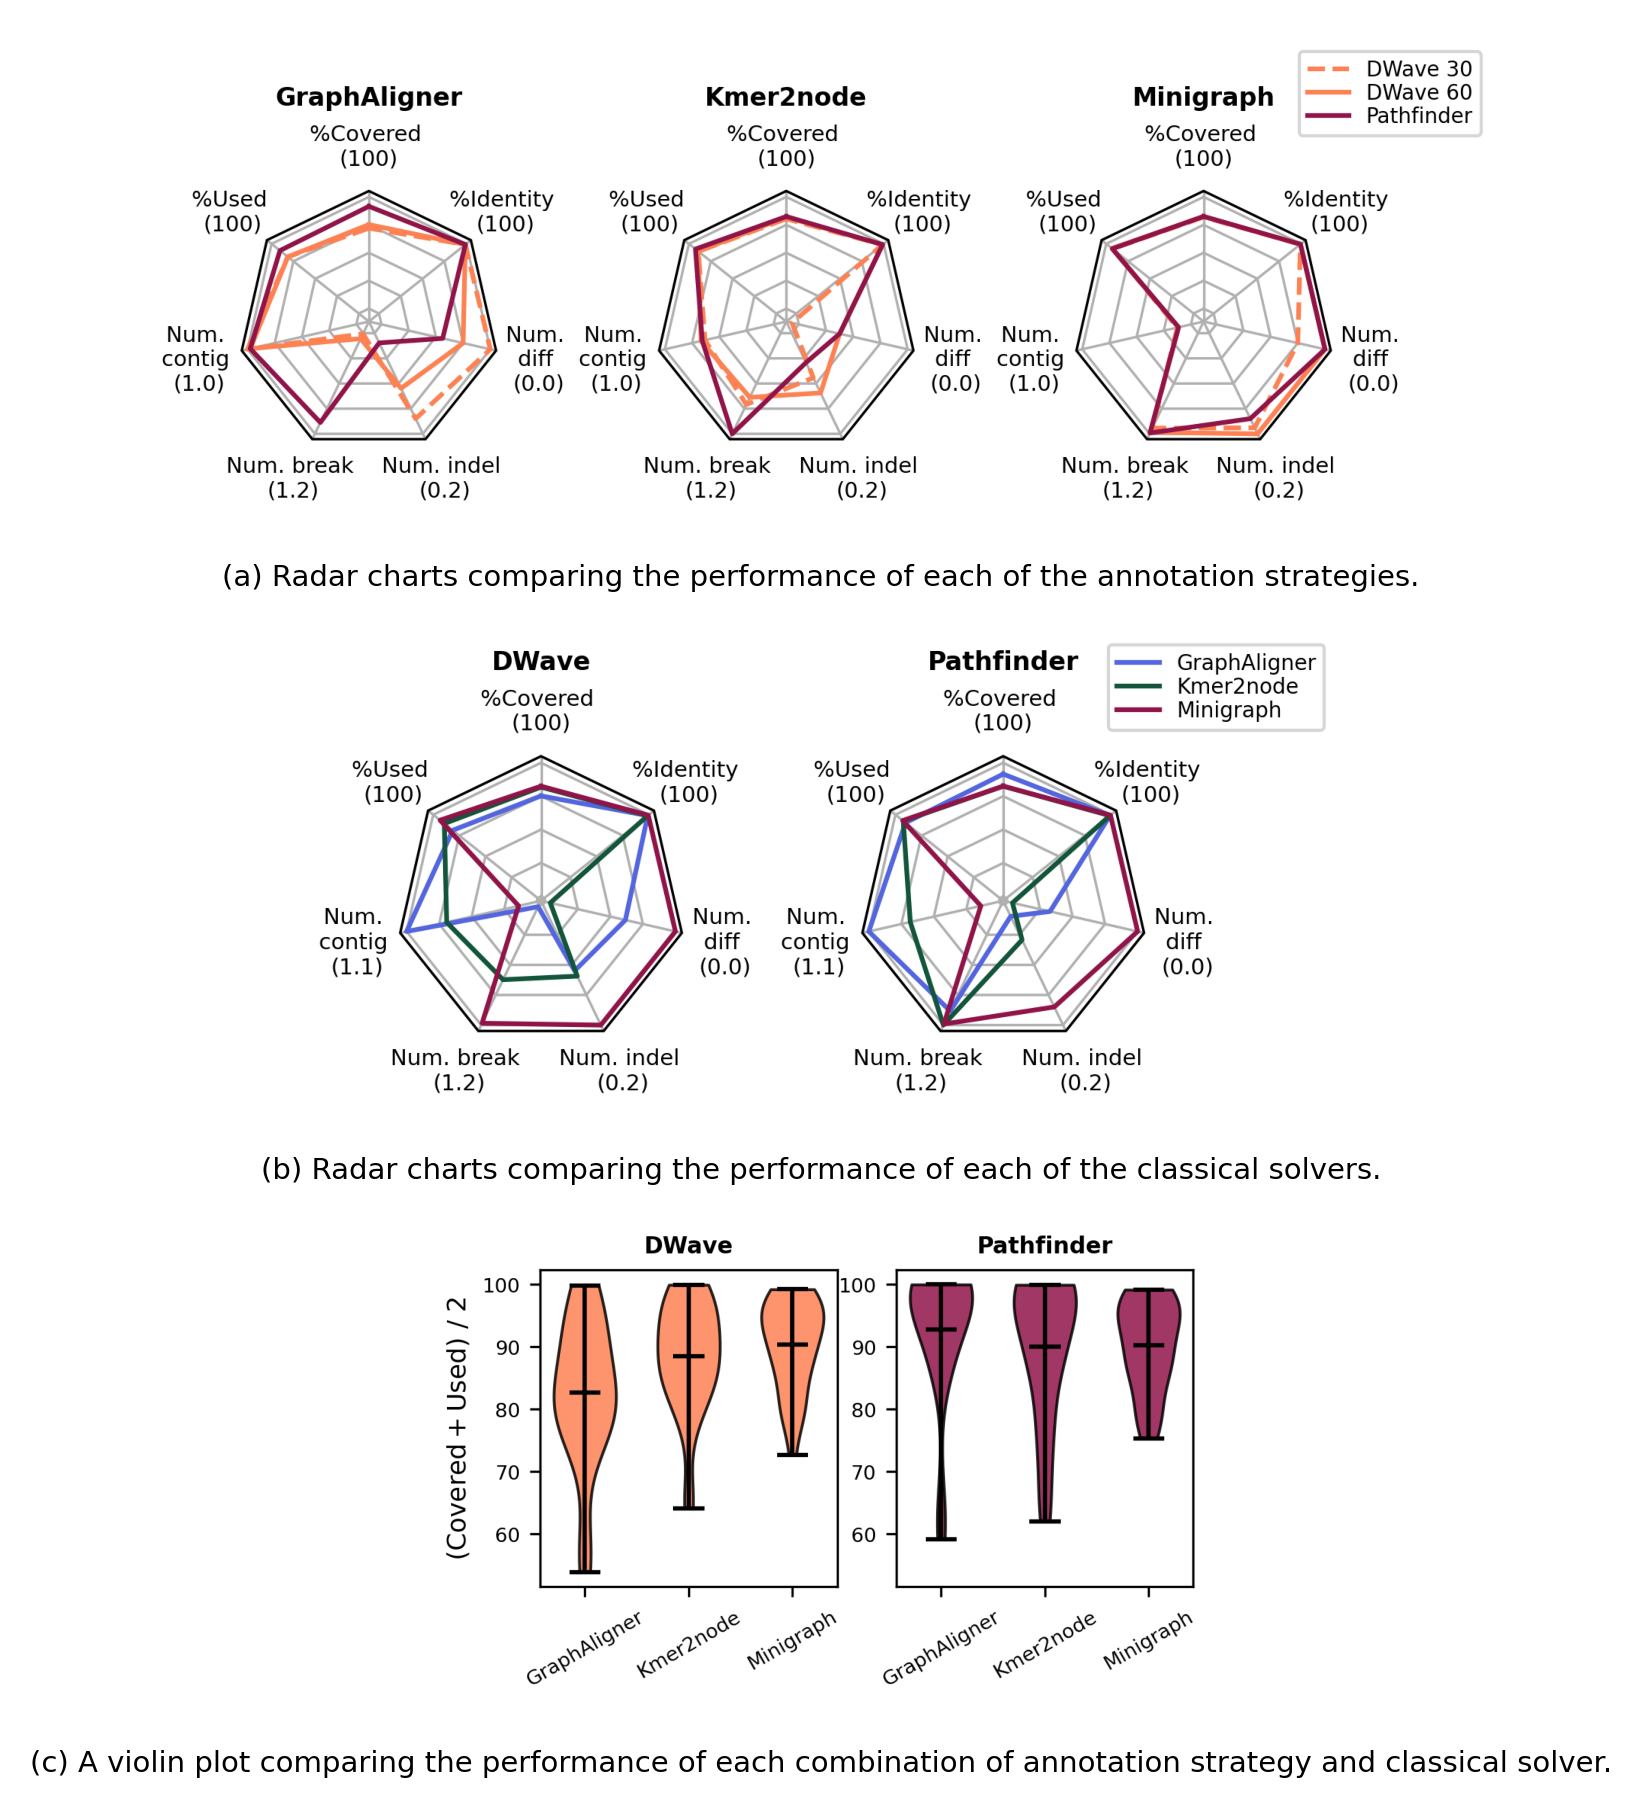

In [86]:
# ---- INPUT FILES (already 300 DPI) ----
images = [
    f'{data_folder}/compare_annotator.{".".join(solvers)}.png',
    f'{data_folder}/compare_solver.{".".join(solvers)}.png',
    f'{data_folder}/violin.{".".join(solvers)}.png',
]

subcaptions = [
    "(a) Radar charts comparing the performance of each of the annotation strategies.",
    "(b) Radar charts comparing the performance of each of the classical solvers.",
    "(c) A violin plot comparing the performance of each combination of annotation strategy and classical solver.",
]

# ---- JOURNAL CONSTRAINTS ----
DPI = 300
TEXTWIDTH_IN = 6.27
PANEL_HEIGHT_IN = 4 * 0.6759999999999999     # adjust if your panels are taller
SMALL_PANEL_HEIGHT_IN = 2
CAPTION_SPACE_IN = 0.3   # vertical space for each subcaption
HEIGHTS = np.array([658, 623, 722]) / DPI

n = len(images)
fig_height = sum(HEIGHTS) + (n-1) * CAPTION_SPACE_IN

# ---- CREATE FIGURE ----
fig, axes = plt.subplots(
    nrows=n,
    ncols=1,
    figsize=(TEXTWIDTH_IN, fig_height),
    dpi=DPI
)

if n == 1:
    axes = [axes]

# ---- LOAD & PLACE IMAGES ----
for ax, img_path, caption in zip(axes, images, subcaptions):
    img = mpimg.imread(img_path)
    ax.imshow(img)
    ax.axis("off")

    # subfigure caption (LaTeX-style)
    ax.text(
        0.5, -0.08, caption,
        transform=ax.transAxes,
        ha="center",
        va="top",
        fontsize=7
    )

# ---- FINAL SPACING ----
# fig.subplots_adjust(
#     top=0.98,
#     bottom=0.02,
#     left=0.02,
#     right=0.98,
#     # hspace=0.25
# )

# ---- SAVE ----
fig.savefig(
    f'{data_folder}/combined.{".".join(solvers)}.png',
    dpi=DPI,
    bbox_inches="tight"
)

plt.show()
